# MedSAM2 CT Lesion Inference - Colab Compatible

This notebook provides a demo of CT lesion annotation using MedSAM2, adapted for Google Colab environment. This notebook uses the box prompt on the key slices to segment the 3D CT lesion case.

**Prerequisites:**
- RL-CC-SAM environment with 'llms' virtual environment
- MedSAM2 checkpoints in ./pretrained/ directory  
- CT_DeepLesion dataset in ./datasets/ directory

In [ ]:
# Environment setup and Colab detection
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Running in Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')

    # Set up paths for Colab
    DRIVE_ROOT = '/content/drive/MyDrive'
    PROJECT_ROOT = f'{DRIVE_ROOT}/RL-CC-SAM'

    # Change to project directory
    os.chdir(PROJECT_ROOT)
    sys.path.append(PROJECT_ROOT)

    # Add prebuilt environment to path
    sys.path.append(f"{DRIVE_ROOT}/colab_envs/llms/lib/python3.11/site-packages")

    print(f"📁 Working directory: {os.getcwd()}")
else:
    print("💻 Running locally")
    # Assume notebook is in notebooks/ folder
    PROJECT_ROOT = Path.cwd().parent
    os.chdir(PROJECT_ROOT)

    print(f"📁 Working directory: {PROJECT_ROOT}")

# Set up directories following project structure
DATASETS_DIR = Path(PROJECT_ROOT) / "datasets"
PRETRAINED_DIR = Path(PROJECT_ROOT) / "pretrained"
MEDSAM2_DIR = Path(PROJECT_ROOT) / "MedSAM2"

# Add MedSAM2 to Python path for importing MedSAM2 specific functions
sys.path.insert(0, str(MEDSAM2_DIR))

print(f"📊 Datasets directory: {DATASETS_DIR}")
print(f"🧠 Pretrained models directory: {PRETRAINED_DIR}")
print(f"🏥 MedSAM2 directory: {MEDSAM2_DIR}")

# Verify required directories exist
if not MEDSAM2_DIR.exists():
    raise FileNotFoundError(f"MedSAM2 directory not found: {MEDSAM2_DIR}")
if not DATASETS_DIR.exists():
    raise FileNotFoundError(f"Datasets directory not found: {DATASETS_DIR}")
if not PRETRAINED_DIR.exists():
    raise FileNotFoundError(f"Pretrained directory not found: {PRETRAINED_DIR}")

print("✅ Environment setup complete")

🌐 Running in Google Colab
Mounted at /content/drive
📁 Working directory: /content/drive/MyDrive/RL-CC-SAM
📊 Datasets directory: /content/drive/MyDrive/RL-CC-SAM/datasets
🧠 Pretrained models directory: /content/drive/MyDrive/RL-CC-SAM/pretrained
🏥 MedSAM2 directory: /content/drive/MyDrive/RL-CC-SAM/MedSAM2
✅ Environment setup complete


In [ ]:
# load libraries and define necessary functions
from glob import glob
from tqdm import tqdm
import os
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
import argparse

from PIL import Image
import SimpleITK as sitk
import torch
import torch.multiprocessing as mp
from sam2.build_sam import build_sam2_video_predictor_npz
import SimpleITK as sitk
from skimage import measure, morphology

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_float32_matmul_precision('high')
torch.manual_seed(2024)
torch.cuda.manual_seed(2024)
np.random.seed(2024)

## Get largest connected component
## This function takes a binary segmentation mask (an array where pixels belonging to the segmented object are 1 and background is 0) and performs post-processing. It identifies all separate “blobs” or connected regions of foreground pixels. It then finds the largest blob (the one with the most pixels) and returns a new mask containing only this largest region.
def getLargestCC(segmentation):
    labels = measure.label(segmentation) ## Assign unique labels to connected areas
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1 ## Find the largest foreground CC
    return largestCC

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """
    show mask on the image

    Parameters
    ----------
    mask : numpy.ndarray
        mask of the image
    ax : matplotlib.axes.Axes
        axes to plot the mask
    mask_color : numpy.ndarray
        color of the mask
    alpha : float
        transparency of the mask
    """
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax, edgecolor='blue'):
    """
    show bounding box on the image

    Parameters
    ----------
    box : numpy.ndarray
        bounding box coordinates in the original image
    ax : matplotlib.axes.Axes
        axes to plot the bounding box
    edgecolor : str
        color of the bounding box
    """
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=edgecolor, facecolor=(0,0,0,0), lw=2))


def resize_grayscale_to_rgb_and_resize(array, image_size):
    """
    Resize a 3D grayscale NumPy array to an RGB image and then resize it.

    Parameters:
        array (np.ndarray): Input array of shape (d, h, w).
        image_size (int): Desired size for the width and height.

    Returns:
        np.ndarray: Resized array of shape (d, 3, image_size, image_size).
    """
    d, h, w = array.shape
    resized_array = np.zeros((d, 3, image_size, image_size))

    for i in range(d):
        img_pil = Image.fromarray(array[i].astype(np.uint8))
        img_rgb = img_pil.convert("RGB")
        img_resized = img_rgb.resize((image_size, image_size))
        img_array = np.array(img_resized).transpose(2, 0, 1)  # (3, image_size, image_size)
        resized_array[i] = img_array

    return resized_array

def mask2D_to_bbox(gt2D, max_shift=20):
    # ... (implementation for finding the tight bbox around a 2D mask) ...
    # ... (adds optional random coordinate shift) ...
    y_indices, x_indices = np.where(gt2D > 0)
    if len(x_indices) == 0: # Handle empty mask
        return np.array([0, 0, 0, 0]) # Return zero box
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    H, W = gt2D.shape
    bbox_shift = np.random.randint(0, max_shift + 1, 1)[0]
    x_min = max(0, x_min - bbox_shift)
    x_max = min(W-1, x_max + bbox_shift)
    y_min = max(0, y_min - bbox_shift)
    y_max = min(H-1, y_max + bbox_shift)
    boxes = np.array([x_min, y_min, x_max, y_max]) # XYXY format
    return boxes

def mask3D_to_bbox(gt3D, max_shift=20):
    # ... (implementation for finding the tight bbox around a 3D mask) ...
    # ... (adds optional random coordinate shift) ...
    z_indices, y_indices, x_indices = np.where(gt3D > 0)
    if len(x_indices) == 0: # Handle empty mask
        return np.array([0, 0, 0, 0, 0, 0]) # Return zero box
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    z_min, z_max = np.min(z_indices), np.max(z_indices)
    D, H, W = gt3D.shape
    bbox_shift = np.random.randint(0, max_shift + 1, 1)[0]
    x_min = max(0, x_min - bbox_shift)
    x_max = min(W-1, x_max + bbox_shift)
    y_min = max(0, y_min - bbox_shift)
    y_max = min(H-1, y_max + bbox_shift)
    z_min = max(0, z_min) # Usually no shift in Z for key slice prompting
    z_max = min(D-1, z_max)
    boxes3d = np.array([x_min, y_min, z_min, x_max, y_max, z_max]) # XYZXYZ format
    return boxes3d

## Calculates the Dice Similarity Coefficient (DSC), a common metric for evaluating segmentation performance. It compares the predicted segmentation (preds) with the ground truth (targets). It calculates the DSC for each distinct object label (ignoring background label 0) and returns the average score.
def dice_multi_class(preds, targets):
    smooth = 1.0
    assert preds.shape == targets.shape
    # Find unique foreground labels in the target mask
    labels = np.unique(targets)[1:]
    dices = []
    for label in labels:
        # Create binary masks for the current label
        pred = preds == label
        target = targets == label
        # Calculate intersection and sum for Dice score
        intersection = (pred * target).sum()
        dices.append((2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth))
    # Return the average Dice score across all foreground labels
    return np.mean(dices)

# Function to check if file is empty (zero bytes)
def is_empty_file(filepath):
    """Check if a file is empty (zero bytes)"""
    try:
        return os.path.getsize(filepath) == 0
    except OSError:
        return True

## 📁 Path Configuration

Configure paths to work with Colab directory structure:

- `checkpoint`: model checkpoint from pretrained directory
- `imgs_path`: path to the 3D volume in `nii.gz` format from datasets
- `model_cfg`: model config path relative to MedSAM2 directory
- `pred_save_dir`: path to save the inference results  
- `path_DL_info`: path to the CT lesion key slices info from datasets

In [ ]:
# Set paths adapted for Colab environment structure
checkpoint = str(PRETRAINED_DIR / 'MedSAM2_latest.pt')
imgs_path = str(DATASETS_DIR / 'CT_DeepLesion-MedSAM2' / 'images')  # Adjust based on your dataset structure
# model_cfg = str(MEDSAM2_DIR / "sam2" / "configs" / "sam2.1_hiera_t512.yaml")
model_cfg = str("configs/sam2.1_hiera_t512.yaml")
pred_save_dir = str(Path(PROJECT_ROOT) / "results" / "CT_DeepLesion_results")
os.makedirs(pred_save_dir, exist_ok=True)

# Path to dataset info - adjust based on your dataset structure
path_DL_info = str(DATASETS_DIR / 'CT_DeepLesion-MedSAM2' / 'DeepLesion_Dataset_Info.csv')

# Verify critical files exist
if not os.path.exists(checkpoint):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint}")
# if not os.path.exists(model_cfg):
#     raise FileNotFoundError(f"Model config not found: {model_cfg}")
if not os.path.exists(path_DL_info):
    print(f"⚠️ Dataset info file not found: {path_DL_info}")
    print("💡 Please ensure CT_DeepLesion dataset is properly downloaded")
if not os.path.exists(imgs_path):
    print(f"⚠️ Images directory not found: {imgs_path}")
    print("💡 Please ensure CT_DeepLesion dataset is properly downloaded")

print(f"✅ Checkpoint: {checkpoint}")
print(f"✅ Model config: {model_cfg}")
print(f"✅ Images path: {imgs_path}")
print(f"✅ Results will be saved to: {pred_save_dir}")

# Load dataset info if available
assert os.path.exists(path_DL_info), f"Dataset info file not found: {path_DL_info}"
DL_info = pd.read_csv(path_DL_info)
print(f"✅ Loaded dataset info with {len(DL_info)} entries")

✅ Checkpoint: /content/drive/MyDrive/RL-CC-SAM/pretrained/MedSAM2_latest.pt
✅ Model config: configs/sam2.1_hiera_t512.yaml
✅ Images path: /content/drive/MyDrive/RL-CC-SAM/datasets/CT_DeepLesion-MedSAM2/images
✅ Results will be saved to: /content/drive/MyDrive/RL-CC-SAM/results/CT_DeepLesion_results
✅ Loaded dataset info with 32735 entries


For the purpose of the demo, we perform segmentation only on a single image in the `imgs_path`.

In [ ]:
# Nii file name used for this demo
if os.path.exists(imgs_path) and os.listdir(imgs_path):
    # Find all '.nii.gz' files in the specified image directory
    nii_fnames = sorted(os.listdir(imgs_path))
    nii_fnames = [i for i in nii_fnames if i.endswith('.nii.gz')]
    # Filter out hidden or temporary files
    nii_fnames = [i for i in nii_fnames if not i.startswith('.')]
    nii_fnames = [i for i in nii_fnames if not is_empty_file(join(imgs_path, i))]
    print(f'Processing {len(nii_fnames)} nii files')
    seg_info = OrderedDict()
    seg_info['nii_name'] = []
    seg_info['key_slice_index'] = []
    seg_info['DICOM_windows'] = []
else:
    raise FileNotFoundError(f"No files found in images directory: {imgs_path}")

Processing 3255 nii files


In [ ]:
# Initialize predictor
print("🧠 Initializing MedSAM2 predictor...")
# The config file path needs to be passed correctly to hydra
# One way is to pass the config file directly to build_sam2_video_predictor_npz
# The build_sam2_video_predictor_npz function already takes config_file as an argument
# So, ensure that the file path is correct and accessible from the environment
predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint)
print("✅ MedSAM2 predictor initialized successfully")

# Process the CT volume
assert 'DL_info' in locals(), "⚠️ No dataset info available"
# Loop through each detected NIfTI file, each for one slice of a lesion
# for nii_fname in tqdm(nii_fnames): ## with a progress bar
for nii_fname in nii_fnames:
  # --- Start processing one NIfTI file ---
  print(f"📄 Processing file: {nii_fname}")
  # Extract slice range and case name from the filename
  range_suffix = re.findall(r'(?<=_)\d{3}-\d{3}', nii_fname)[0]
  slice_range = range_suffix.split('-')
  slice_range = [str(int(s)) for s in slice_range]
  slice_range = ', '.join(slice_range)
  # Load the 3D image volume and convert to NumPy array
  nii_fpath = join(imgs_path, nii_fname)
  nii_image = sitk.ReadImage(nii_fpath)
  nii_image_data = sitk.GetArrayFromImage(nii_image) # Shape: (Depth, Height, Width)
  # Find matching lesion entries in the CSV for this scan file
  case_name = re.findall(r'^(\d{6}_\d{2}_\d{2})', nii_fname)[0] ## PatientID_StudyID_SeriesID
  ## Same SeriesID might have different slice_range, e.g. 000050_01_01_058 and 000050_01_01_148
  ## (PatientID_StudyID_SeriesID_SliceRange) is unique among input .nii.gz files, but not unique for slice image files in .csv info file
  case_df = DL_info[
      DL_info['File_name'].str.contains(case_name) &
      DL_info['Slice_range'].str.contains(slice_range)
  ].copy()
  if len(case_df) == 0:
      print(f"⚠️ No matching case found in dataset info for {case_name}")
      print("💡 Using default processing parameters")
      # Use default values if no dataset info available
      key_slice_idx_offset = nii_image_data.shape[0] // 2
      bbox = np.array([64, 64, 192, 192])  # Default bounding box
      lower_bound, upper_bound = -200, 200  # Default CT window
  else:
      # Initialize an empty 3D array for the combined segmentation mask of this volume
      segs_3D_volume = np.zeros(nii_image_data.shape, dtype=np.uint8)
      # Loop through each lesion found in the CSV for this NIfTI file
      for row_id, row in case_df.iterrows():
          # --- Start processing one lesion within the NIfTI file ---
          # [Lesion processing code follows inside this inner loop]
          # ...
          # get the key slice info and preprocess image
          lower_bound, upper_bound = row['DICOM_windows'].split(',')
          lower_bound, upper_bound = float(lower_bound), float(upper_bound)
          # Apply windowing and normalize to 0-255 (uint8)
          nii_image_data_pre = np.clip(nii_image_data, lower_bound, upper_bound)
          nii_image_data_pre = (nii_image_data_pre - np.min(nii_image_data_pre))/(np.max(nii_image_data_pre)-np.min(nii_image_data_pre))*255.0
          nii_image_data_pre = np.uint8(nii_image_data_pre)
          # Get key slice index and bounding box
          key_slice_idx = int(row['Key_slice_index'])
          slice_range = row['Slice_range']
          slice_idx_start, slice_idx_end = slice_range.split(',')
          slice_idx_start, slice_idx_end = int(slice_idx_start), int(slice_idx_end)
          key_slice_idx_offset = key_slice_idx - slice_idx_start

          bbox_coords = row['Bounding_boxes'].split(',')
          bbox_coords = [int(float(coord)) for coord in bbox_coords]
          bbox = np.array([bbox_coords[1], bbox_coords[0], bbox_coords[3], bbox_coords[2]])  # x_min, y_min, x_max, y_max

          # Store the preprocessed 3D volume data for this lesion
          img_3D_ori = nii_image_data_pre
          print(f"📐 Image shape: {img_3D_ori.shape}")
          print(f"🎯 Key slice offset: {key_slice_idx_offset} ({key_slice_idx} in {slice_idx_start}-{slice_idx_end})")
          print(f"📦 Bounding box: {bbox}")
          assert np.max(img_3D_ori) < 256, f'input data should be in range [0, 255], but got {np.unique(img_3D_ori)}'

          # Get original height/width for resizing outputs later
          key_slice_img = nii_image_data_pre[key_slice_idx_offset, :,:]
          video_height, video_width = key_slice_img.shape[0], key_slice_img.shape[1]
          # 2. Prepare Input for MedSAM2 Model
          # Resize slices to 512x512 and convert to RGB format
          img_resized = resize_grayscale_to_rgb_and_resize(img_3D_ori, 512) # Shape: (D, 3, 512, 512)
          # Normalize pixel values to 0.0-1.0
          img_resized = img_resized / 255.0
          # Convert to PyTorch tensor and move to GPU
          img_resized = torch.from_numpy(img_resized).to(device)
          # Define and apply ImageNet normalization
          img_mean=(0.485, 0.456, 0.406)
          img_std=(0.229, 0.224, 0.225)
          img_mean = torch.tensor(img_mean, dtype=torch.float32)[:, None, None].to(device)
          img_std = torch.tensor(img_std, dtype=torch.float32)[:, None, None].to(device)
          img_resized -= img_mean
          img_resized /= img_std

          # 3. Run MedSAM2 Inference for the current lesion
          print("🚀 Starting MedSAM2 inference...")
          segs_3D_lesion = np.zeros(nii_image_data.shape, dtype=np.uint8) # Mask for this specific lesion
          # Use inference mode and mixed precision for efficiency
          with torch.inference_mode(), torch.autocast(device.type, dtype=torch.bfloat16):
              # Initialize predictor state with the volume data
              inference_state = predictor.init_state(img_resized, video_height, video_width)
              # Add the initial bounding box prompt on the key slice
              ### if propagate_with_box: ... else ... use GT to get bbox
              predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx_offset,
                obj_id=1, # Assign ID 1 to this lesion object
                box=bbox,
              )
              # Propagate segmentation FORWARD from the key slice
              for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state):
                  binary_mask = (out_mask_logits[0] > 0.0).cpu().numpy()[0]
                  segs_3D_lesion[out_frame_idx, binary_mask] = 1 # Mark segmented pixels

              # Reset predictor state (clear memory) before backward pass
              predictor.reset_state(inference_state)
              # Add the initial prompt AGAIN for the backward pass
              ### if propagate_with_box: ... else ... use GT to get bbox
              predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx_offset,
                obj_id=1,
                box=bbox,
              )
              # Propagate segmentation BACKWARD from the key slice
              for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
                  binary_mask = (out_mask_logits[0] > 0.0).cpu().numpy()[0]
                  segs_3D_lesion[out_frame_idx, binary_mask] = 1 # Update mask (union)

              # Reset state after finishing this lesion
              predictor.reset_state(inference_state)
          # 4. Post-process the segmentation for the current lesion
          if np.max(segs_3D_lesion) > 0:
              # Keep only the largest connected component (removes noise)
              segs_3D_lesion = getLargestCC(segs_3D_lesion)
              segs_3D_lesion = np.uint8(segs_3D_lesion)
          # 5. Combine the current lesion's segmentation with the volume's segmentation
          # Use logical OR to merge masks if multiple lesions exist in the volume
          segs_3D_volume = np.logical_or(segs_3D_volume, segs_3D_lesion).astype(np.uint8)
          # --- End processing one lesion --- (Inner loop finishes here) ---
  # --- End processing one NIfTI file --- (Outer loop continues after this) ---
  # 6. Save Results for the entire NIfTI volume
  # Convert final NumPy mask to SimpleITK image
  sitk_mask = sitk.GetImageFromArray(segs_3D_volume)
  # Copy spatial metadata from original NIfTI
  sitk_mask.CopyInformation(nii_image)
  # Prepare the preprocessed image (from last lesion) for saving
  sitk_image_preprocessed = sitk.GetImageFromArray(img_3D_ori)
  sitk_image_preprocessed.CopyInformation(nii_image)
  # Define output filenames
  key_slice_idx_csv = int(row['Key_slice_index']) # Key slice from the last processed row
  save_seg_name = nii_fname.split('.nii.gz')[0] + f'_k{key_slice_idx_csv}_mask.nii.gz'
  save_img_name = nii_fname.replace('.nii.gz', '_img.nii.gz')
  # Write the preprocessed image and the final segmentation mask to disk
  sitk.WriteImage(sitk_image_preprocessed, os.path.join(pred_save_dir, save_img_name))
  sitk.WriteImage(sitk_mask, os.path.join(pred_save_dir, save_seg_name))
  # Record metadata about the saved segmentation
  seg_info['nii_name'].append(save_seg_name)
  seg_info['key_slice_index'].append(key_slice_idx_csv)
  seg_info['DICOM_windows'].append(row['DICOM_windows'])
  # --- (Outer loop continues to the next nii_fname) ---

🧠 Initializing MedSAM2 predictor...
✅ MedSAM2 predictor initialized successfully
📄 Processing file: 000001_02_01_008-023_0000.nii.gz
📐 Image shape: (16, 512, 512)
🎯 Key slice offset: 6 (14 in 8-23)
📦 Bounding box: [284 217 310 233]
🚀 Starting MedSAM2 inference...


propagate in video: 100%|██████████| 7/7 [00:00<00:00, 39.25it/s]


📐 Image shape: (16, 512, 512)
🎯 Key slice offset: 9 (17 in 8-23)
📦 Bounding box: [258 229 325 285]
🚀 Starting MedSAM2 inference...


propagate in video: 100%|██████████| 10/10 [00:00<00:00, 37.23it/s]


📄 Processing file: 000002_02_01_044-083_0000.nii.gz
📐 Image shape: (40, 512, 512)
🎯 Key slice offset: 33 (77 in 44-83)
📦 Bounding box: [207 223 228 245]
🚀 Starting MedSAM2 inference...


...

propagate in video: 100%|██████████| 7/7 [00:00<00:00, 34.84it/s]


📄 Processing file: 004454_01_01_110-122.nii.gz
📐 Image shape: (13, 512, 512)
🎯 Key slice offset: 6 (116 in 110-122)
📦 Bounding box: [289 231 340 293]
🚀 Starting MedSAM2 inference...


propagate in video: 100%|██████████| 7/7 [00:00<00:00, 34.99it/s]


📄 Processing file: 004458_01_01_096-108.nii.gz
📐 Image shape: (13, 512, 512)
🎯 Key slice offset: 6 (102 in 96-108)
📦 Bounding box: [347 215 373 281]
🚀 Starting MedSAM2 inference...


propagate in video: 100%|██████████| 7/7 [00:00<00:00, 36.37it/s]


In [ ]:
print(slice_range)

['_008', '023']


In [ ]:
print("✅ MedSAM2 inference completed successfully!")
print(f"💾 Results saved to: {pred_save_dir}")
# save the segmentation info to a csv file
seg_info_df = pd.DataFrame(seg_info)
seg_info_df.to_csv(join(pred_save_dir, 'seg_info_colab.csv'), index=False)
print(f"📊 Segmentation info saved to: {join(pred_save_dir, 'seg_info_colab.csv')}")

In [ ]:
# Set up evaluation paths
labels_path = str(DATASETS_DIR / 'CT_DeepLesion-MedSAM2' / 'labels')
print(f"📁 Ground truth labels path: {labels_path}")

# Check if labels directory exists
if not os.path.exists(labels_path):
    print(f"⚠️ Labels directory not found: {labels_path}")
    print("💡 Please ensure ground truth labels are available for evaluation")
    labels_available = False
else:
    labels_available = True
    print("✅ Labels directory found")

📁 Ground truth labels path: /content/drive/MyDrive/RL-CC-SAM/datasets/CT_DeepLesion-MedSAM2/labels
✅ Labels directory found


In [ ]:
# Function to get valid file pairs (non-empty images and labels)
def get_valid_file_pairs(imgs_path, labels_path):
    """Get pairs of image and label files that are non-empty"""
    valid_pairs = []

    if not os.path.exists(imgs_path) or not os.path.exists(labels_path):
        return valid_pairs

    # Get all nii.gz files from images directory
    img_files = [f for f in os.listdir(imgs_path) if f.endswith('.nii.gz') and not f.startswith('._')]
    ## Input image filename sample:
    ## Corresponding label(mask) filename sample:
    for img_file in img_files:
        img_path = os.path.join(imgs_path, img_file)
        label_path = os.path.join(labels_path, img_file)  # Assuming same filename for label

        # Check if both files exist and are non-empty
        if (os.path.exists(img_path) and os.path.exists(label_path) and
            not is_empty_file(img_path) and not is_empty_file(label_path)):
            valid_pairs.append((img_file, img_path, label_path))
        else:
            if not os.path.exists(label_path):
                print(f"⚠️ No corresponding label found for {img_file}")
            elif is_empty_file(img_path):
                print(f"⚠️ Empty image file: {img_file}")
            elif is_empty_file(label_path):
                print(f"⚠️ Empty label file: {img_file}")

    return valid_pairs

# Evaluate segmentation performance
if labels_available:
    print("\n🔍 Starting evaluation...")

    # Get valid file pairs
    valid_pairs = get_valid_file_pairs(imgs_path, labels_path)
    print(f"📊 Found {len(valid_pairs)} valid image-label pairs")

    if len(valid_pairs) == 0:
        print("❌ No valid image-label pairs found for evaluation")
    else:
        # Initialize results storage
        evaluation_results = []

        # Process each valid pair
        for img_file, img_path, label_path in tqdm(valid_pairs, desc="Evaluating"):
            try:
                # Find corresponding prediction file
                pred_files = [f for f in os.listdir(pred_save_dir) if f.startswith(img_file.replace('.nii.gz', '')) and f.endswith('_mask.nii.gz')]

                if len(pred_files) == 0:
                    print(f"⚠️ No prediction found for {img_file}")
                    continue

                pred_file = pred_files[0]  # Take the first matching prediction
                pred_path = os.path.join(pred_save_dir, pred_file)

                if is_empty_file(pred_path):
                    print(f"⚠️ Empty prediction file: {pred_file}")
                    continue

                # Load prediction and ground truth
                pred_sitk = sitk.ReadImage(pred_path)
                pred_array = sitk.GetArrayFromImage(pred_sitk)

                gt_sitk = sitk.ReadImage(label_path)
                gt_array = sitk.GetArrayFromImage(gt_sitk)

                # Check if shapes match
                if pred_array.shape != gt_array.shape:
                    print(f"⚠️ Shape mismatch for {img_file}: pred {pred_array.shape} vs gt {gt_array.shape}")
                    continue

                # Calculate Dice score
                dice_score = dice_multi_class(pred_array, gt_array)

                # Store results
                evaluation_results.append({
                    'image_file': img_file,
                    'prediction_file': pred_file,
                    'dice_score': dice_score,
                    'pred_shape': pred_array.shape,
                    'gt_shape': gt_array.shape,
                    'pred_nonzero': np.sum(pred_array > 0),
                    'gt_nonzero': np.sum(gt_array > 0)
                })

                print(f"✅ {img_file}: Dice = {dice_score:.4f}")

            except Exception as e:
                print(f"❌ Error processing {img_file}: {str(e)}")
                continue

        # Save evaluation results
        if evaluation_results:
            eval_df = pd.DataFrame(evaluation_results)
            eval_csv_path = os.path.join(pred_save_dir, 'evaluation_results.csv')
            eval_df.to_csv(eval_csv_path, index=False)

            # Print summary statistics
            print(f"\n📊 Evaluation Summary:")
            print(f"   Total evaluated cases: {len(evaluation_results)}")
            print(f"   Mean Dice Score: {eval_df['dice_score'].mean():.4f} ± {eval_df['dice_score'].std():.4f}")
            print(f"   Median Dice Score: {eval_df['dice_score'].median():.4f}")
            print(f"   Min Dice Score: {eval_df['dice_score'].min():.4f}")
            print(f"   Max Dice Score: {eval_df['dice_score'].max():.4f}")
            print(f"   Results saved to: {eval_csv_path}")
        else:
            print("❌ No successful evaluations completed")
else:
    print("⚠️ Skipping evaluation - ground truth labels not available")



🔍 Starting evaluation...
⚠️ Empty image file: 000515_01_01_001-008.nii.gz
⚠️ Empty image file: 002648_02_01_261-387.nii.gz
⚠️ Empty image file: 000937_02_01_149-209.nii.gz
⚠️ Empty image file: 002250_04_01_251-311.nii.gz
⚠️ Empty image file: 000260_11_03_125-185.nii.gz
⚠️ Empty image file: 002819_01_01_054-063.nii.gz
⚠️ Empty image file: 001939_01_02_290-350.nii.gz
⚠️ Empty image file: 001902_01_01_013-029.nii.gz
⚠️ Empty image file: 000260_11_01_098-115.nii.gz
⚠️ Empty image file: 000111_02_01_055-073.nii.gz
⚠️ Empty image file: 002336_02_01_185-245.nii.gz
⚠️ Empty image file: 001189_06_01_066-078.nii.gz
⚠️ Empty image file: 002177_02_01_059-081.nii.gz
⚠️ Empty image file: 002794_01_01_076-090.nii.gz
⚠️ Empty image file: 000826_03_01_092-152.nii.gz
⚠️ Empty image file: 000495_02_01_053-076.nii.gz
⚠️ Empty image file: 000553_07_02_121-184.nii.gz
⚠️ Empty image file: 002630_04_02_019-031.nii.gz
⚠️ Empty image file: 002836_05_02_339-399.nii.gz
⚠️ Empty image file: 001071_03_02_215-275.n

Evaluating:   0%|          | 1/3157 [00:27<24:13:26, 27.63s/it]

✅ 002135_04_01_110-128.nii.gz: Dice = 0.9256


Evaluating:   0%|          | 2/3157 [00:28<10:25:41, 11.90s/it]

✅ 002207_02_01_073-089.nii.gz: Dice = 0.7570


...

✅ 000204_05_01_038-061.nii.gz: Dice = 0.0000


Evaluating: 100%|█████████▉| 3156/3157 [1:00:34<00:00,  1.54it/s]

✅ 000242_02_01_052-076.nii.gz: Dice = 0.9382


Evaluating: 100%|██████████| 3157/3157 [1:00:34<00:00,  1.15s/it]

✅ 000214_01_01_033-054.nii.gz: Dice = 0.7578

📊 Evaluation Summary:
   Total evaluated cases: 3157
   Mean Dice Score: 0.7100 ± 0.3104
   Median Dice Score: 0.8536
   Min Dice Score: 0.0000
   Max Dice Score: 0.9922
   Results saved to: /content/drive/MyDrive/RL-CC-SAM/results/CT_DeepLesion_results/evaluation_results.csv


# Optional: Realization of the segmentation
In the following, we show the image and the overlayed segmentation slices of 25 percentile, key slice, and 75 percentile

🎨 Starting visualization...
🎲 Randomly selected case
📄 Visualizing: 000625_05_02_045-105.nii.gz
🔍 Prediction: 000625_05_02_045-105_k75_mask.nii.gz


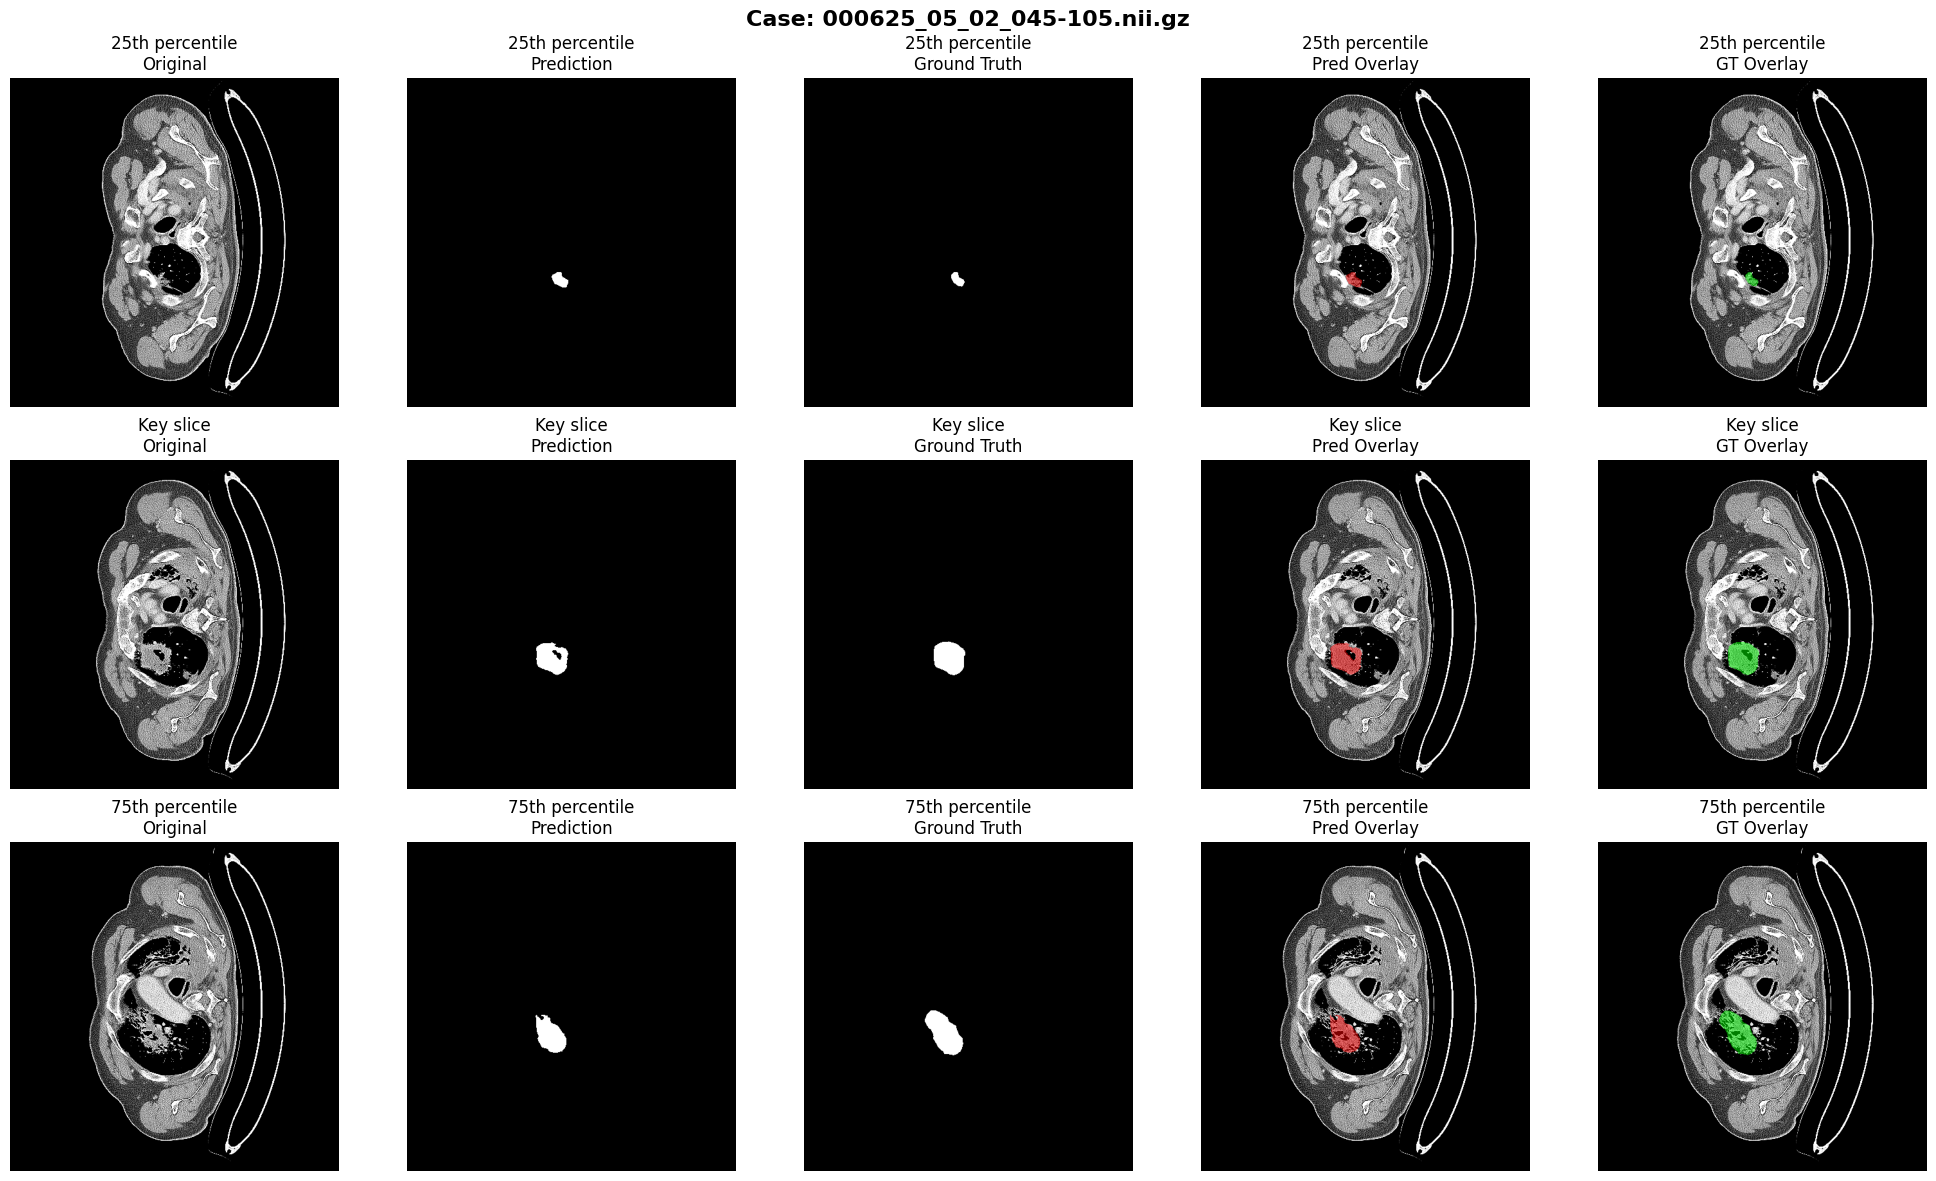

🎯 Dice Score: 0.7091
📊 Prediction volume: 68285 voxels
📊 Ground truth volume: 106465 voxels
✅ Visualization completed successfully!


In [ ]:
# Configuration for visualization
VISUALIZE_INDEX = None  # Set to specific index (e.g., 0) or None for random selection
VISUALIZE_RANDOM = True  # Set to True for random selection

# Function to visualize a single case
def visualize_case(img_file, img_path, label_path, pred_path, bbox_info=None):
    """
    Visualize a single case with original image, prediction, and ground truth
    """
    try:
        # Load images
        img_sitk = sitk.ReadImage(img_path)
        img_array = sitk.GetArrayFromImage(img_sitk)

        pred_sitk = sitk.ReadImage(pred_path)
        pred_array = sitk.GetArrayFromImage(pred_sitk)

        gt_sitk = sitk.ReadImage(label_path)
        gt_array = sitk.GetArrayFromImage(gt_sitk)

        # Get preprocessed image if available (apply same windowing as during inference)
        if 'DL_info' in locals() and not DL_info.empty:
            # Try to find matching case info
            case_name = re.findall(r'^(\d{6}_\d{2}_\d{2})', img_file)[0]
            matching_cases = DL_info[DL_info['File_name'].str.contains(case_name)]

            if len(matching_cases) > 0:
                # Use windowing from dataset info
                window_info = matching_cases.iloc[0]['DICOM_windows']
                lower_bound, upper_bound = window_info.split(',')
                lower_bound, upper_bound = float(lower_bound), float(upper_bound)

                # Apply windowing and normalize
                img_display = np.clip(img_array, lower_bound, upper_bound)
                img_display = (img_display - np.min(img_display))/(np.max(img_display)-np.min(img_display))*255.0
                img_display = np.uint8(img_display)

                # Get bounding box info if available
                if bbox_info is None:
                    bbox_coords = matching_cases.iloc[0]['Bounding_boxes'].split(',')
                    bbox_coords = [int(float(coord)) for coord in bbox_coords]
                    bbox_info = np.array([bbox_coords[1], bbox_coords[0], bbox_coords[3], bbox_coords[2]])  # x_min, y_min, x_max, y_max

                # Get key slice info
                key_slice_idx = int(matching_cases.iloc[0]['Key_slice_index'])
                slice_range = matching_cases.iloc[0]['Slice_range']
                slice_idx_start, slice_idx_end = slice_range.split(',')
                slice_idx_start, slice_idx_end = int(slice_idx_start), int(slice_idx_end)
                key_slice_idx_offset = key_slice_idx - slice_idx_start
            else:
                # Use default windowing
                img_display = np.clip(img_array, -200, 200)
                img_display = (img_display - np.min(img_display))/(np.max(img_display)-np.min(img_display))*255.0
                img_display = np.uint8(img_display)
                key_slice_idx_offset = img_array.shape[0] // 2
                bbox_info = None
        else:
            # Use default windowing
            img_display = np.clip(img_array, -200, 200)
            img_display = (img_display - np.min(img_display))/(np.max(img_display)-np.min(img_display))*255.0
            img_display = np.uint8(img_display)
            key_slice_idx_offset = img_array.shape[0] // 2
            bbox_info = None

        # Select slices to visualize
        slice_indices = np.arange(0, img_array.shape[0])
        if len(slice_indices) > 1:
            slice_idx_25 = int(np.percentile(slice_indices, 25))
            slice_idx_75 = int(np.percentile(slice_indices, 75))
            percentile_slices = [slice_idx_25, key_slice_idx_offset, slice_idx_75]
        else:
            percentile_slices = [0, 0, 0]

        # Create visualization
        fig, axes = plt.subplots(3, 5, figsize=(20, 12))
        fig.suptitle(f'Case: {img_file}', fontsize=16, fontweight='bold')

        for ax in axes.flatten():
            ax.axis('off')

        slice_labels = ['25th percentile', 'Key slice', '75th percentile']
        col_titles = ['Original', 'Prediction', 'Ground Truth', 'Pred Overlay', 'GT Overlay']

        for row_idx, (slice_idx, slice_label) in enumerate(zip(percentile_slices, slice_labels)):
            # Ensure slice index is within bounds
            slice_idx = max(0, min(slice_idx, img_array.shape[0] - 1))

            # Get 2D slices
            img_2D = img_display[slice_idx]
            pred_2D = pred_array[slice_idx]
            gt_2D = gt_array[slice_idx]

            # Original image
            axes[row_idx, 0].imshow(img_2D, cmap='gray')
            axes[row_idx, 0].set_title(f'{slice_label}\nOriginal', fontsize=12)

            # Add bounding box on key slice
            if bbox_info is not None and slice_idx == key_slice_idx_offset:
                show_box(bbox_info, axes[row_idx, 0], edgecolor='red')

            # Prediction mask
            axes[row_idx, 1].imshow(pred_2D, cmap='gray')
            axes[row_idx, 1].set_title(f'{slice_label}\nPrediction', fontsize=12)

            # Ground truth mask
            axes[row_idx, 2].imshow(gt_2D, cmap='gray')
            axes[row_idx, 2].set_title(f'{slice_label}\nGround Truth', fontsize=12)

            # Prediction overlay
            axes[row_idx, 3].imshow(img_2D, cmap='gray')
            if np.any(pred_2D > 0):
                show_mask(pred_2D, axes[row_idx, 3], mask_color=np.array([1.0, 0.0, 0.0]))  # Red for prediction
            axes[row_idx, 3].set_title(f'{slice_label}\nPred Overlay', fontsize=12)

            # Ground truth overlay
            axes[row_idx, 4].imshow(img_2D, cmap='gray')
            if np.any(gt_2D > 0):
                show_mask(gt_2D, axes[row_idx, 4], mask_color=np.array([0.0, 1.0, 0.0]))  # Green for ground truth
            axes[row_idx, 4].set_title(f'{slice_label}\nGT Overlay', fontsize=12)

            # Add bounding box on key slice overlays
            if bbox_info is not None and slice_idx == key_slice_idx_offset:
                show_box(bbox_info, axes[row_idx, 3], edgecolor='blue')
                show_box(bbox_info, axes[row_idx, 4], edgecolor='blue')

        plt.tight_layout()
        plt.show()

        # Calculate and display dice score
        dice_score = dice_multi_class(pred_array, gt_array)
        print(f"🎯 Dice Score: {dice_score:.4f}")
        print(f"📊 Prediction volume: {np.sum(pred_array > 0)} voxels")
        print(f"📊 Ground truth volume: {np.sum(gt_array > 0)} voxels")

        return True

    except Exception as e:
        print(f"❌ Error visualizing {img_file}: {str(e)}")
        return False

# Main visualization logic
if labels_available and 'valid_pairs' in locals() and len(valid_pairs) > 0:
    print("🎨 Starting visualization...")

    # Select case to visualize
    if VISUALIZE_INDEX is not None:
        if 0 <= VISUALIZE_INDEX < len(valid_pairs):
            selected_pair = valid_pairs[VISUALIZE_INDEX]
            print(f"📋 Visualizing case at index {VISUALIZE_INDEX}")
        else:
            print(f"⚠️ Index {VISUALIZE_INDEX} out of range. Using random selection.")
            selected_pair = valid_pairs[np.random.randint(0, len(valid_pairs))]
            print(f"🎲 Randomly selected case")
    else:
        # Random selection
        selected_pair = valid_pairs[np.random.randint(0, len(valid_pairs))]
        print(f"🎲 Randomly selected case")

    img_file, img_path, label_path = selected_pair

    # Find corresponding prediction file
    pred_files = [f for f in os.listdir(pred_save_dir) if f.startswith(img_file.replace('.nii.gz', '')) and f.endswith('_mask.nii.gz')]

    if len(pred_files) == 0:
        print(f"❌ No prediction found for {img_file}")
    else:
        pred_file = pred_files[0]
        pred_path = os.path.join(pred_save_dir, pred_file)

        print(f"📄 Visualizing: {img_file}")
        print(f"🔍 Prediction: {pred_file}")

        # Visualize the case
        success = visualize_case(img_file, img_path, label_path, pred_path)

        if success:
            print("✅ Visualization completed successfully!")
        else:
            print("❌ Visualization failed!")

elif not labels_available:
    print("⚠️ Cannot visualize comparison - ground truth labels not available")
    print("💡 Showing prediction-only visualization...")

    # Fallback: show prediction only (original visualization logic)
    if 'img_3D_ori' in locals() and 'segs_3D_volume' in locals():
        # Use the last processed case
        slice_indices = np.arange(0, img_3D_ori.shape[0])
        if len(slice_indices) > 1:
            slice_idx_25 = int(np.percentile(slice_indices, 25))
            slice_idx_75 = int(np.percentile(slice_indices, 75))
            percentile_slices = [slice_idx_25, key_slice_idx_offset, slice_idx_75]
        else:
            percentile_slices = [0, 0, 0]

        fig, axes = plt.subplots(3, 2, figsize=(10, 15))
        for ax in axes.flatten():
            ax.axis('off')

        row_titles = ['25th percentile', 'Key slice', '75th percentile']
        col_titles = ['Original', 'Prediction Overlay']

        for row_idx, (slice_idx, slice_label) in enumerate(zip(percentile_slices, row_titles)):
            slice_idx = max(0, min(slice_idx, img_3D_ori.shape[0] - 1))

            img_2D = img_3D_ori[slice_idx]
            seg_2D = segs_3D_volume[slice_idx]

            axes[row_idx, 0].imshow(img_2D, cmap='gray')
            axes[row_idx, 0].set_title(f'{slice_label}\nOriginal', fontsize=12)

            axes[row_idx, 1].imshow(img_2D, cmap='gray')
            if np.any(seg_2D > 0):
                show_mask(seg_2D, axes[row_idx, 1])
            axes[row_idx, 1].set_title(f'{slice_label}\nPrediction', fontsize=12)

        plt.tight_layout()
        plt.show()

    else:
        print("❌ No data available for visualization")
else:
    print("❌ No valid data available for visualization")